In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [2]:
# For the outlier detection algorhthym, we will employ the following
# 1.  Z - Score
# 2. IQR : Lower Bound = Q1 - (1.5 x [Q3-Q1]) | Upper Bound = Q3 + (1.5 x [Q3-Q1])
# 3. Isolation forest = Works on the principle that outliers are "easier to isolate" than normal points

# We will not use the Elliptic Envelop as it follows and assumes that the data is Gaussian

# We notice that our data has low correlation which a non-linear relationship could exists (hence not using the Elliptic Envelop)

In [4]:

gcs_path = '../data/House Price Prediction Dataset.csv'

# Load the CSV directly from GCS
df = pd.read_csv(gcs_path)
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [12]:


def detect_outliers(df, numeric_columns=['Area', 'Price', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']):
    """
    Outlier detection using Z-Score, IQR, and Isolation Forest with consistent green theme
    """
    # Set seaborn style
    sns.set_theme(style="whitegrid")
    
    # Define color scheme
    colors = {
        'normal': '#7CB342',      # Main green for normal points
        'iqr': '#33691E',         # Orange for IQR outliers
        'zscore': '#33691E',      # Dark green for Z-score outliers
        'isolation': '#33691E',   # Light green for isolation forest
        'bounds': '#2E7D32',      # Dark green for boundary lines
        'background': '#F1F8E9'   # Light green background
    }
    
    results = {}
    
    for column in numeric_columns:
        # Calculate outliers
        z_scores = np.abs(stats.zscore(df[column]))
        z_score_outliers = df[z_scores > 3]
        
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        iqr_outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
        
        # Store results
        results[column] = {
            'z_score_outliers': z_score_outliers,
            'iqr_outliers': iqr_outliers,
            'z_score_count': len(z_score_outliers),
            'iqr_count': len(iqr_outliers),
            'bounds': {
                'iqr_lower': Q1 - 1.5 * IQR,
                'iqr_upper': Q3 + 1.5 * IQR,
                'z_score_lower': df[column].mean() - 3 * df[column].std(),
                'z_score_upper': df[column].mean() + 3 * df[column].std()
            }
        }
        
        # Create figure with green theme
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig.patch.set_facecolor(colors['background'])
        
        # Distribution plot
        ax1.set_facecolor(colors['background'])
        sns.histplot(df[column], kde=True, color=colors['normal'], ax=ax1)
        
        # Add bounds
        ax1.axvline(Q1 - 1.5 * IQR, color=colors['iqr'], linestyle='--', 
                   alpha=0.8, label='IQR bounds')
        ax1.axvline(Q3 + 1.5 * IQR, color=colors['iqr'], linestyle='--', 
                   alpha=0.8)
        ax1.axvline(df[column].mean() - 3 * df[column].std(), 
                   color=colors['bounds'], linestyle='--', 
                   alpha=0.8, label='Z-score bounds')
        ax1.axvline(df[column].mean() + 3 * df[column].std(), 
                   color=colors['bounds'], linestyle='--', 
                   alpha=0.8)
        
        ax1.set_title(f'Distribution of {column} with Outlier Bounds', 
                     pad=15, fontsize=12)
        ax1.legend(fontsize=10)
        
        # Scatter plot
        ax2.set_facecolor(colors['background'])
        if column != 'Price':
            sns.scatterplot(data=df, x=column, y='Price', 
                          color=colors['normal'], alpha=0.5, 
                          label='Normal points', ax=ax2)
            sns.scatterplot(data=iqr_outliers, x=column, y='Price', 
                          color=colors['iqr'], alpha=0.7, 
                          label='IQR outliers', ax=ax2)
            sns.scatterplot(data=z_score_outliers, x=column, y='Price', 
                          color=colors['zscore'], alpha=0.7, 
                          label='Z-score outliers', ax=ax2)
        else:
            sns.scatterplot(data=df, x='Area', y='Price', 
                          color=colors['normal'], alpha=0.5, 
                          label='Normal points', ax=ax2)
            sns.scatterplot(data=iqr_outliers, x='Area', y=column, 
                          color=colors['iqr'], alpha=0.7, 
                          label='IQR outliers', ax=ax2)
            sns.scatterplot(data=z_score_outliers, x='Area', y=column, 
                          color=colors['zscore'], alpha=0.7, 
                          label='Z-score outliers', ax=ax2)
        
        ax2.set_title(f'{column} vs Price with Outliers', 
                     pad=15, fontsize=12)
        ax2.legend(fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    # Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    numeric_data = df[numeric_columns].copy()
    numeric_data = StandardScaler().fit_transform(numeric_data)
    outlier_labels = iso_forest.fit_predict(numeric_data)
    multivariate_outliers = df[outlier_labels == -1]
    
    # Visualize multivariate outliers with green theme
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor(colors['background'])
    sns.scatterplot(data=df, x='Area', y='Price', 
                   color=colors['normal'], alpha=0.5, 
                   label='Normal points')
    sns.scatterplot(data=multivariate_outliers, x='Area', y='Price', 
                   color=colors['isolation'], alpha=0.7, 
                   label='Isolation Forest outliers')
    plt.title('Multivariate Outliers (Isolation Forest)', 
             pad=15, fontsize=12)
    plt.legend(fontsize=10)
    plt.show()
    
    # Store multivariate results
    results['multivariate'] = {
        'isolation_forest_outliers': multivariate_outliers,
        'isolation_forest_count': len(multivariate_outliers)
    }
    
    return results

def print_outlier_summary(results):
    """
    Print detailed summary of outlier detection results
    """
    print("\nOutlier Detection Summary:")
    print("=" * 50)
    
    for column, result in results.items():
        if column != 'multivariate':
            print(f"\n{column}:")
            print(f"Z-score outliers (>3 std): {result['z_score_count']}")
            print(f"IQR outliers: {result['iqr_count']}")
            print("\nBounds:")
            print(f"IQR bounds: [{result['bounds']['iqr_lower']:.2f}, "
                  f"{result['bounds']['iqr_upper']:.2f}]")
            print(f"Z-score bounds: [{result['bounds']['z_score_lower']:.2f}, "
                  f"{result['bounds']['z_score_upper']:.2f}]")
        else:
            print(f"\nMultivariate outliers:")
            print(f"Isolation Forest outliers: {result['isolation_forest_count']}")

def compare_methods(results):
    """
    Compare outliers identified by different methods
    """
    print("\nComparison of Outlier Detection Methods:")
    print("=" * 50)
    
    for column in results.keys():
        if column != 'multivariate':
            z_score_indices = set(results[column]['z_score_outliers'].index)
            iqr_indices = set(results[column]['iqr_outliers'].index)
            
            common_outliers = z_score_indices.intersection(iqr_indices)
            z_score_only = z_score_indices - iqr_indices
            iqr_only = iqr_indices - z_score_indices
            
            print(f"\n{column}:")
            print(f"Outliers identified by both methods: {len(common_outliers)}")
            print(f"Outliers unique to Z-score: {len(z_score_only)}")
            print(f"Outliers unique to IQR: {len(iqr_only)}")

# Usage example:
# results = detect_outliers(df)
# print_outlier_summary(results)
# compare_methods(results)

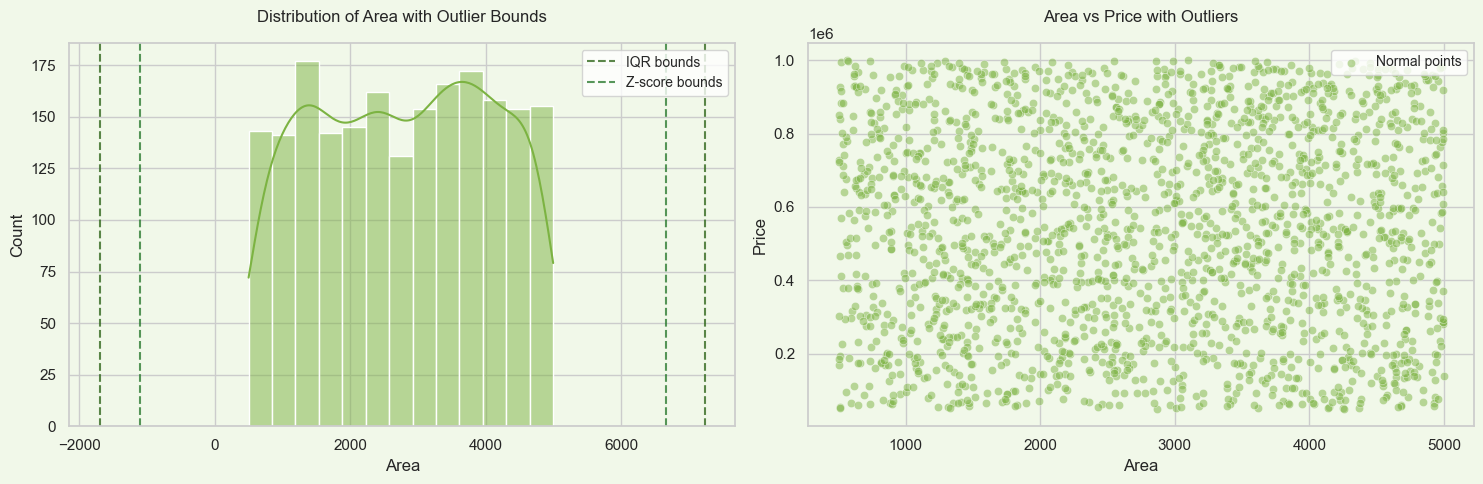

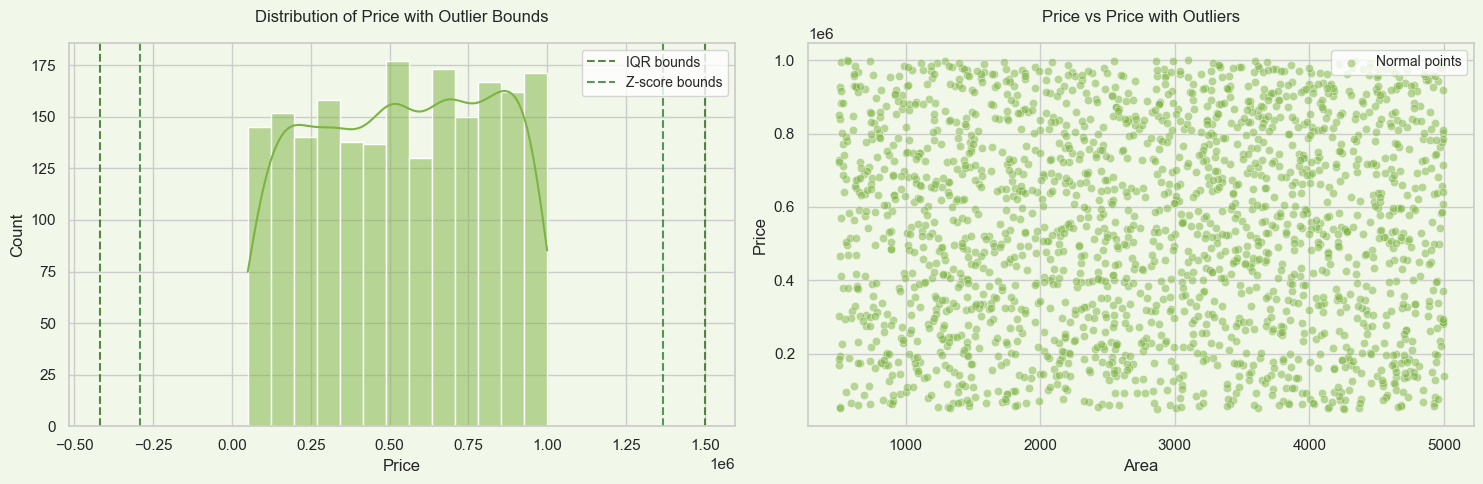

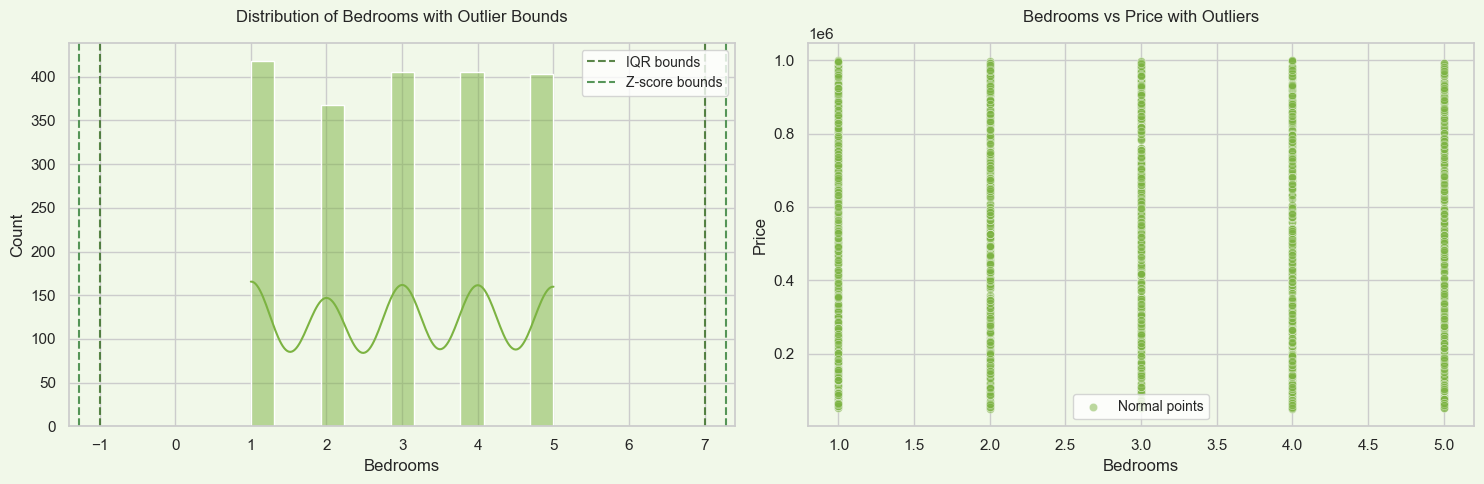

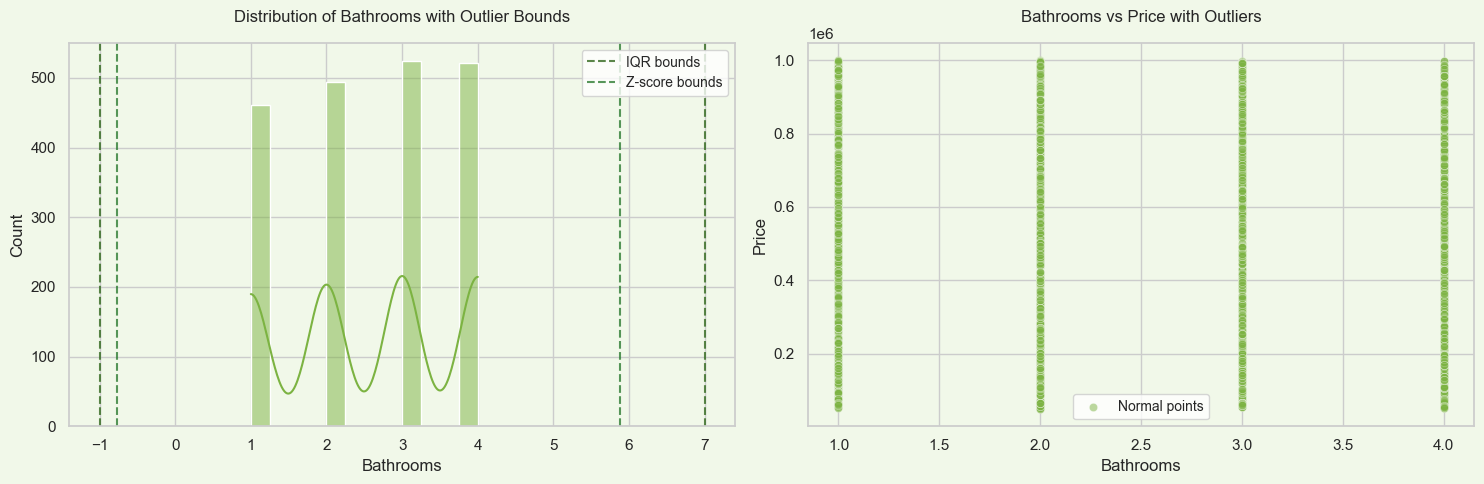

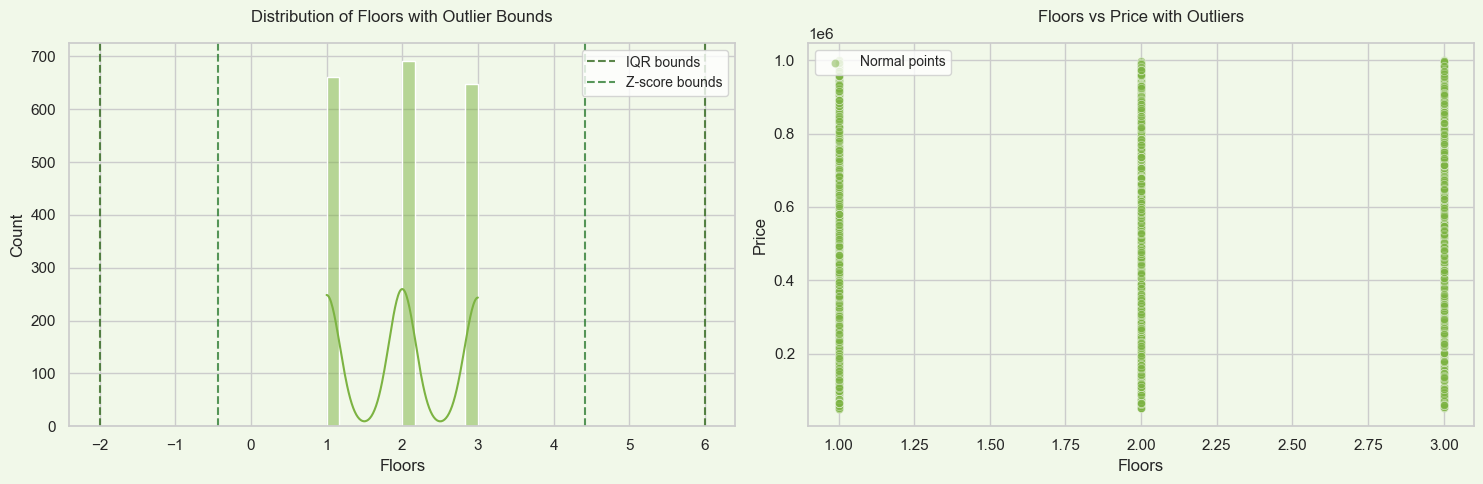

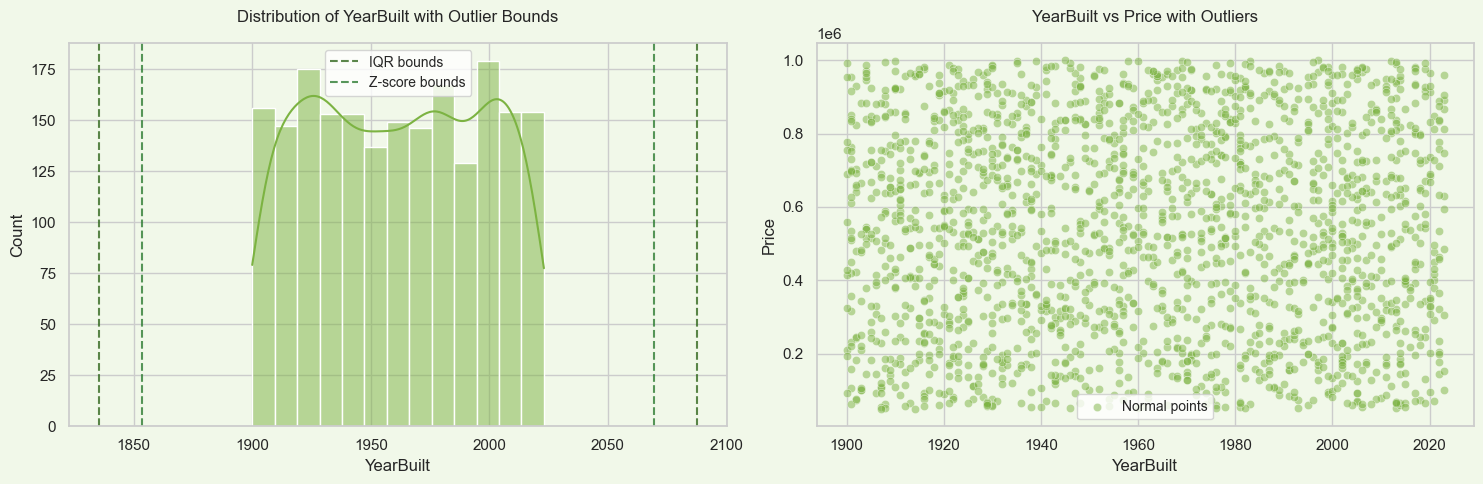

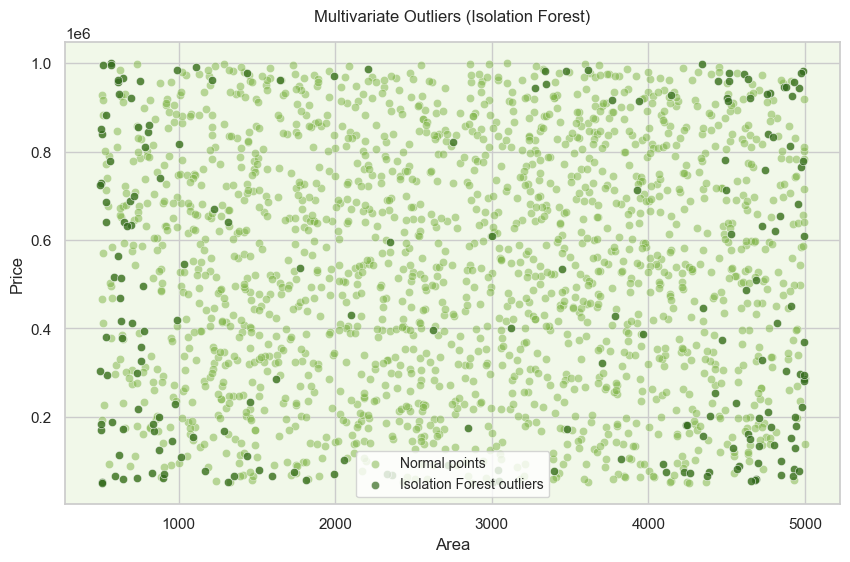


Outlier Detection Summary:

Area:
Z-score outliers (>3 std): 0
IQR outliers: 0

Bounds:
IQR bounds: [-1698.75, 7239.25]
Z-score bounds: [-1099.23, 6671.65]

Price:
Z-score outliers (>3 std): 0
IQR outliers: 0

Bounds:
IQR bounds: [-419884.00, 1500068.00]
Z-score bounds: [-291609.68, 1366963.39]

Bedrooms:
Z-score outliers (>3 std): 0
IQR outliers: 0

Bounds:
IQR bounds: [-1.00, 7.00]
Z-score bounds: [-1.27, 7.28]

Bathrooms:
Z-score outliers (>3 std): 0
IQR outliers: 0

Bounds:
IQR bounds: [-1.00, 7.00]
Z-score bounds: [-0.77, 5.88]

Floors:
Z-score outliers (>3 std): 0
IQR outliers: 0

Bounds:
IQR bounds: [-2.00, 6.00]
Z-score bounds: [-0.43, 4.42]

YearBuilt:
Z-score outliers (>3 std): 0
IQR outliers: 0

Bounds:
IQR bounds: [1835.50, 2087.50]
Z-score bounds: [1853.67, 2069.23]

Multivariate outliers:
Isolation Forest outliers: 200

Comparison of Outlier Detection Methods:

Area:
Outliers identified by both methods: 0
Outliers unique to Z-score: 0
Outliers unique to IQR: 0

Price:
Ou

In [13]:
# Run the outlier detection
results = detect_outliers(df)

# Print the summaries
print_outlier_summary(results)
compare_methods(results)

In [10]:


def analyze_outliers_vs_normal(df):
    """
    Perform comparative analysis between outlier and normal properties with consistent green theme
    """
    # Set seaborn style
    sns.set_theme(style="whitegrid")
    
    # Define color scheme
    colors = {
        'normal': '#7CB342',      # Main green for normal properties
        'outlier': '#33691E',     # Dark green for outliers
        'background': '#F1F8E9',  # Light green background
        'bars': ['#7CB342', '#33691E']  # For bar plots
    }
    
    # Identify outliers using Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    outlier_labels = iso_forest.fit_predict(df[['Area', 'Price']])
    
    # Add outlier labels to dataframe
    df_analysis = df.copy()
    df_analysis['is_outlier'] = outlier_labels == -1
    
    # Split into outlier and normal datasets
    outliers = df_analysis[df_analysis['is_outlier']]
    normal = df_analysis[~df_analysis['is_outlier']]
    
    # 1. Basic Statistics Comparison
    numeric_cols = ['Price', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
    stats_comparison = pd.DataFrame()
    
    for group, data in [('Normal', normal), ('Outlier', outliers)]:
        stats = data[numeric_cols].agg(['mean', 'median', 'std']).round(2)
        stats.columns = [f'{group}_{stat}' for stat in stats.columns]
        stats_comparison = pd.concat([stats_comparison, stats], axis=1)
    
    print("\nNumerical Features Comparison:")
    print("=" * 80)
    print(stats_comparison)
    
    # 2. Categorical Features Analysis
    categorical_cols = ['Location', 'Condition', 'Garage']
    
    for col in categorical_cols:
        print(f"\n{col} Distribution Comparison:")
        print("=" * 80)
        
        normal_dist = normal[col].value_counts(normalize=True) * 100
        outlier_dist = outliers[col].value_counts(normalize=True) * 100
        
        comparison = pd.DataFrame({
            'Normal_%': normal_dist,
            'Outlier_%': outlier_dist
        }).round(2)
        
        print(comparison)
        
        # Visualization with green theme
        fig, ax = plt.subplots(figsize=(12, 5))
        fig.patch.set_facecolor(colors['background'])
        ax.set_facecolor(colors['background'])
        
        width = 0.35
        x = np.arange(len(comparison.index))
        
        ax.bar(x - width/2, comparison['Normal_%'], width, 
               label='Normal', alpha=0.8, color=colors['normal'])
        ax.bar(x + width/2, comparison['Outlier_%'], width, 
               label='Outlier', alpha=0.8, color=colors['outlier'])
        
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel('Percentage', fontsize=12)
        ax.set_title(f'{col} Distribution: Normal vs Outlier Properties', 
                    pad=15, fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(comparison.index, rotation=45)
        ax.legend()
        plt.tight_layout()
        plt.show()
    
    # 3. Price per Square Foot Analysis
    df_analysis['price_per_sqft'] = df_analysis['Price'] / df_analysis['Area']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.patch.set_facecolor(colors['background'])
    
    # Box plot
    ax1.set_facecolor(colors['background'])
    sns.boxplot(data=df_analysis, x='is_outlier', y='price_per_sqft', 
                ax=ax1, palette=colors['bars'])
    ax1.set_title('Price per Square Foot Distribution', pad=15, fontsize=12)
    ax1.set_yscale('log')
    
    # Scatter plot
    ax2.set_facecolor(colors['background'])
    normal_scatter = ax2.scatter(normal['Area'], normal['Price'], 
                               alpha=0.6, c=colors['normal'], label='Normal')
    outlier_scatter = ax2.scatter(outliers['Area'], outliers['Price'], 
                                alpha=0.6, c=colors['outlier'], label='Outlier')
    ax2.set_title('Price vs Area by Outlier Status', pad=15, fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 4. Age Analysis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.patch.set_facecolor(colors['background'])
    
    # Box plot
    ax1.set_facecolor(colors['background'])
    sns.boxplot(data=df_analysis, x='is_outlier', y='YearBuilt', 
                ax=ax1, palette=colors['bars'])
    ax1.set_title('Year Built Distribution', pad=15, fontsize=12)
    
    # Histogram
    ax2.set_facecolor(colors['background'])
    sns.histplot(data=df_analysis, x='YearBuilt', hue='is_outlier', 
                multiple="dodge", bins=20, ax=ax2, 
                palette=colors['bars'])
    ax2.set_title('Year Built Distribution by Outlier Status', 
                  pad=15, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Size Characteristics
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
    fig.patch.set_facecolor(colors['background'])
    
    axes = [ax1, ax2, ax3]
    features = ['Bedrooms', 'Bathrooms', 'Floors']
    
    for ax, feature in zip(axes, features):
        ax.set_facecolor(colors['background'])
        sns.boxplot(data=df_analysis, x='is_outlier', y=feature, 
                   ax=ax, palette=colors['bars'])
        ax.set_title(f'{feature} Distribution', pad=15, fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    return df_analysis

def get_extreme_examples(df_analysis, n=5):
    """
    Get examples of the most extreme outliers
    """
    outliers = df_analysis[df_analysis['is_outlier']]
    
    print("\nMost Expensive Outliers:")
    print("=" * 80)
    print(outliers.nlargest(n, 'Price')[['Price', 'Area', 'Location', 
                                        'Condition', 'YearBuilt']])
    
    print("\nLargest Area Outliers:")
    print("=" * 80)
    print(outliers.nlargest(n, 'Area')[['Price', 'Area', 'Location', 
                                       'Condition', 'YearBuilt']])
    
    print("\nMost Expensive per Square Foot Outliers:")
    print("=" * 80)
    print(outliers.nlargest(n, 'price_per_sqft')
          [['Price', 'Area', 'Location', 'Condition', 'YearBuilt', 
            'price_per_sqft']])

# Usage example:
# df_with_outliers = analyze_outliers_vs_normal(df)
# get_extreme_examples(df_with_outliers)


Numerical Features Comparison:
        Normal_Price  Normal_Area  Normal_Bedrooms  Normal_Bathrooms  \
mean       541579.49      2817.44             3.02              2.56   
median     540436.00      2866.50             3.00              3.00   
std        261125.40      1207.06             1.43              1.11   

        Normal_Floors  Normal_YearBuilt  Outlier_Price  Outlier_Area  \
mean             1.99           1961.75      502553.10       2505.16   
median           2.00           1962.00      468105.50       1528.00   
std              0.81             35.89      387024.34       1894.77   

        Outlier_Bedrooms  Outlier_Bathrooms  Outlier_Floors  Outlier_YearBuilt  
mean                2.82               2.46            2.04            1958.74  
median              3.00               2.00            2.00            1958.50  
std                 1.41               1.09            0.82              36.20  

Location Distribution Comparison:
          Normal_%  Outlier_%
L

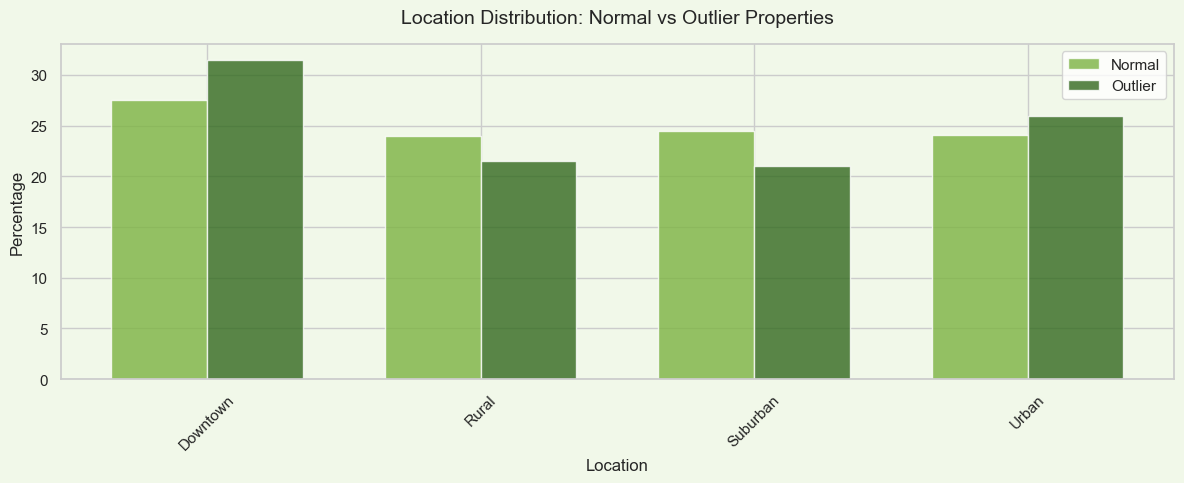


Condition Distribution Comparison:
           Normal_%  Outlier_%
Condition                     
Excellent     25.50       26.0
Fair          26.33       23.5
Good          23.28       21.0
Poor          24.89       29.5


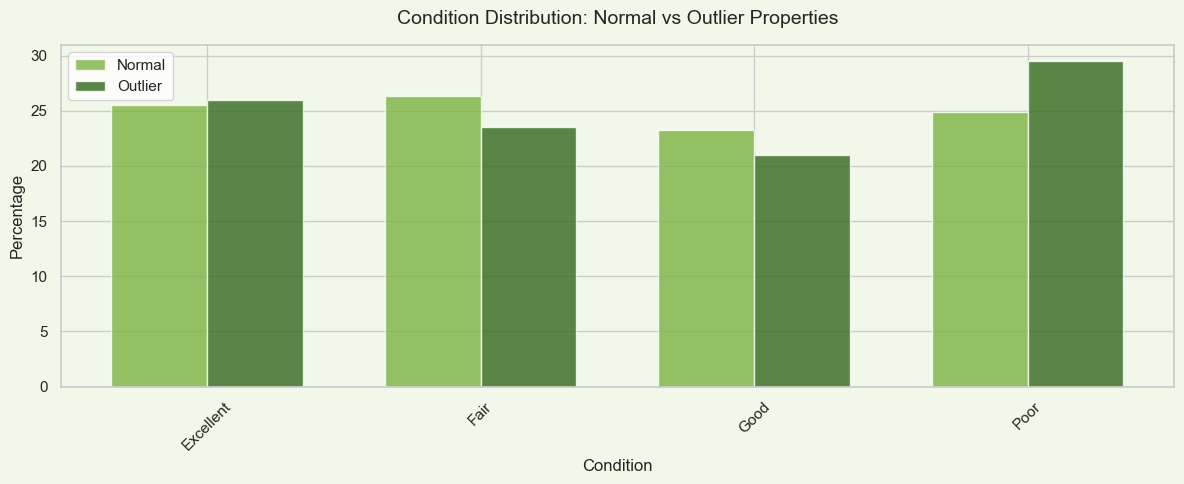


Garage Distribution Comparison:
        Normal_%  Outlier_%
Garage                     
No         51.89       52.0
Yes        48.11       48.0


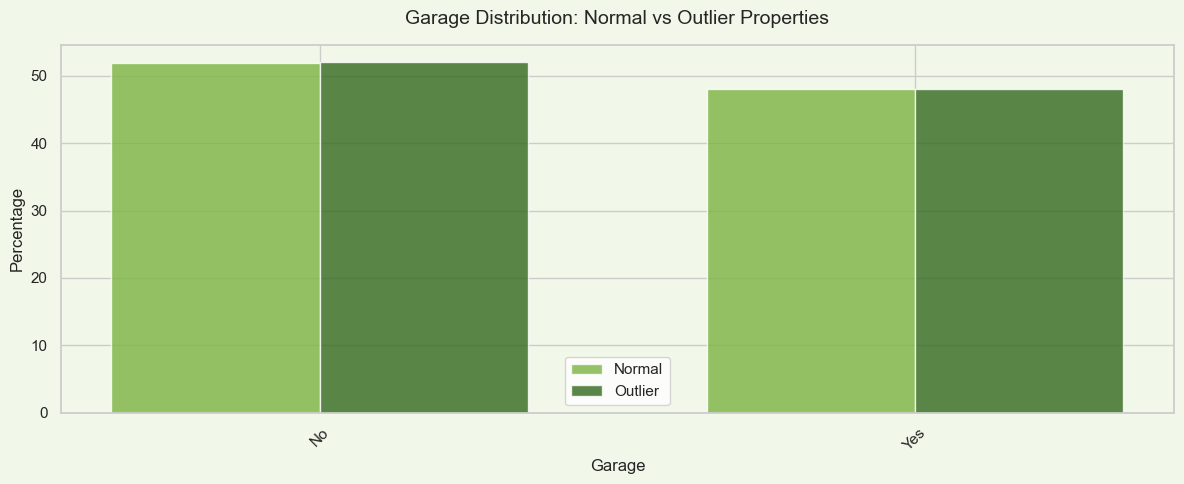

C:\Users\User\AppData\Local\Temp\ipykernel_28200\3758910046.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_outlier', y='price_per_sqft',


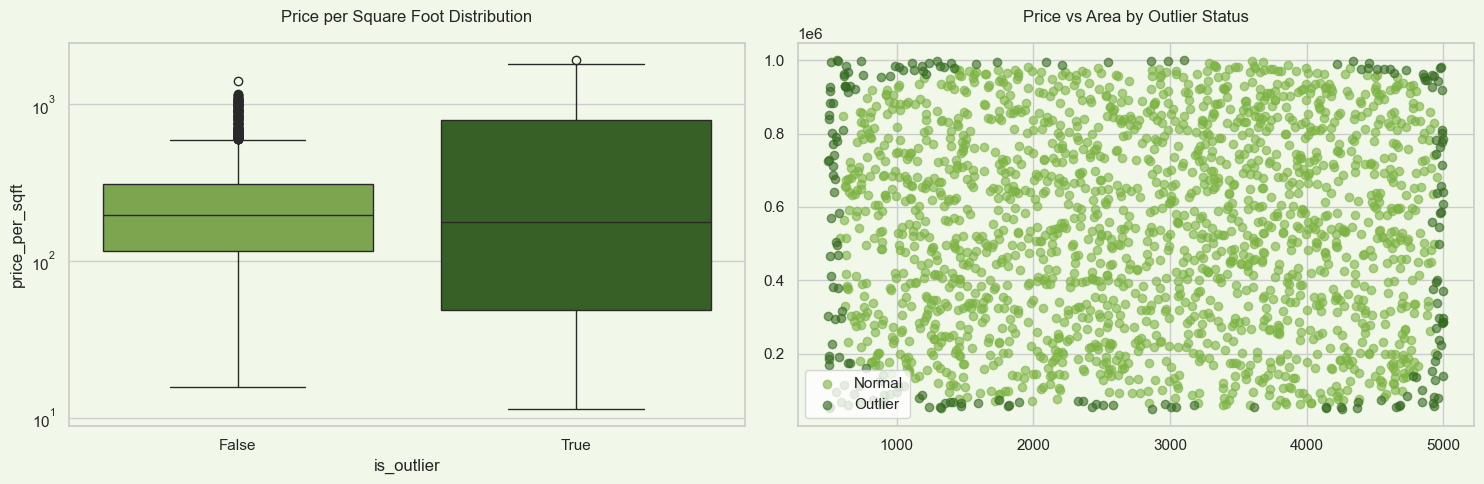

C:\Users\User\AppData\Local\Temp\ipykernel_28200\3758910046.py:112: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_outlier', y='YearBuilt',


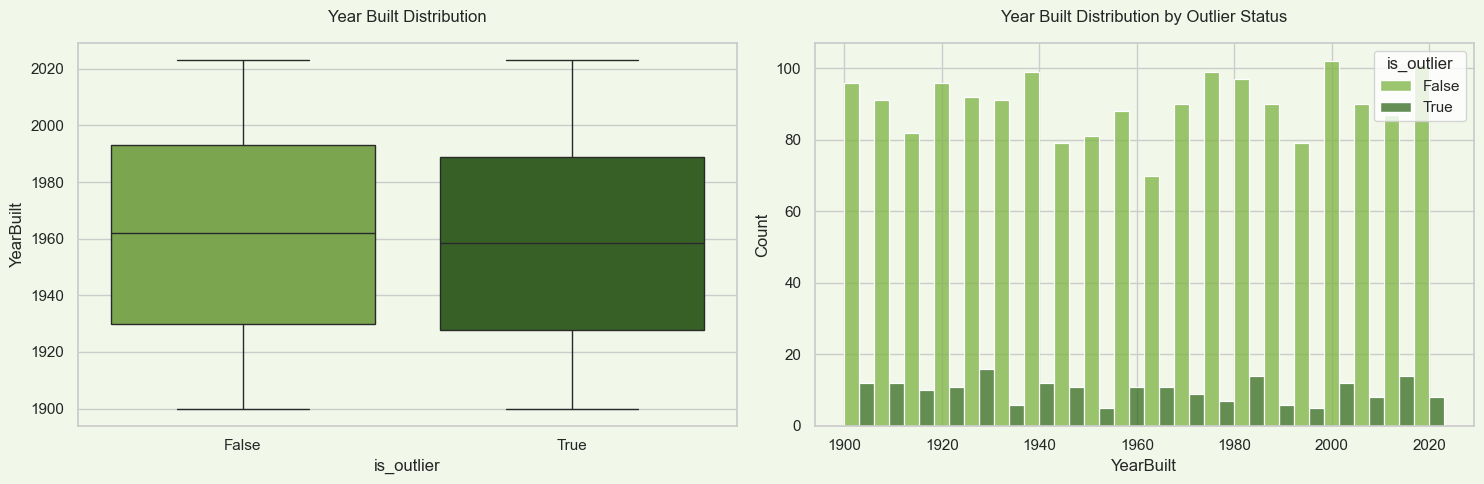

C:\Users\User\AppData\Local\Temp\ipykernel_28200\3758910046.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_outlier', y=feature,
C:\Users\User\AppData\Local\Temp\ipykernel_28200\3758910046.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_outlier', y=feature,
C:\Users\User\AppData\Local\Temp\ipykernel_28200\3758910046.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='is_outlier', y=feature,


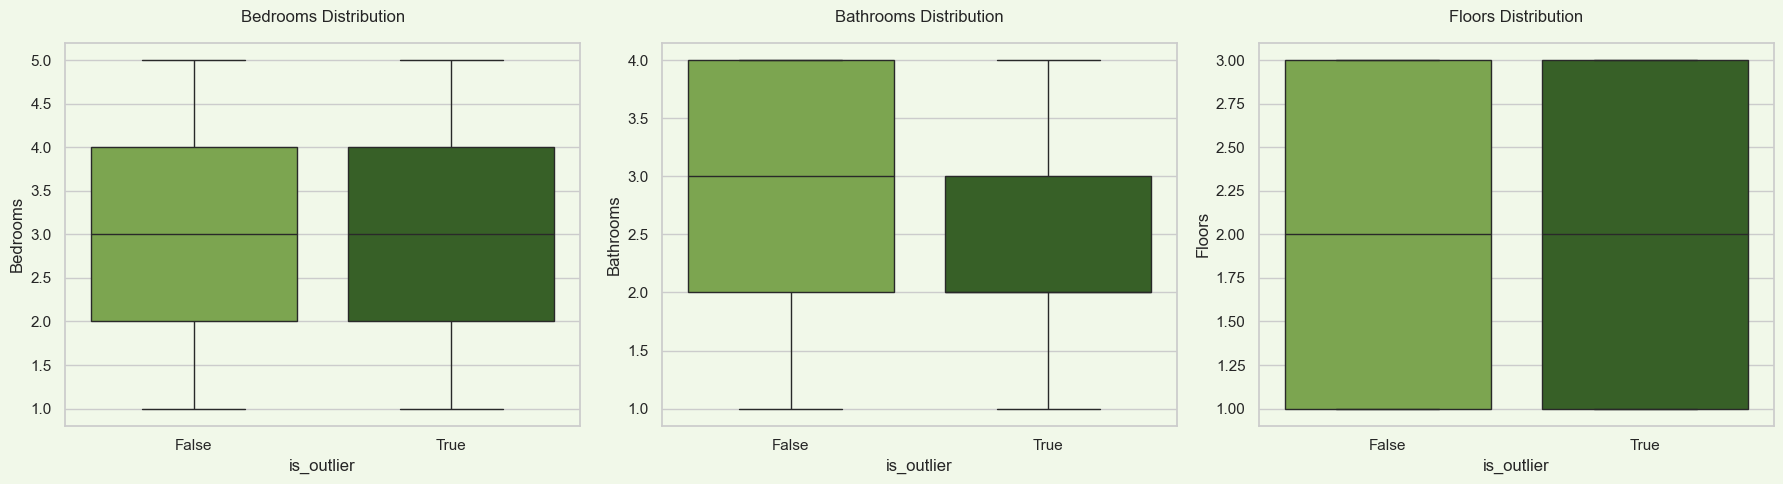


Most Expensive Outliers:
       Price  Area  Location Condition  YearBuilt
1004  999656  3099  Suburban      Good       1997
1787  999453   566     Urban      Fair       1945
1006  998128   736  Downtown      Good       1939
1552  998084  2860  Downtown      Fair       1910
241   997719  2985     Urban      Poor       1969

Largest Area Outliers:
       Price  Area  Location  Condition  YearBuilt
205   139460  4999  Downtown  Excellent       1967
1122  286887  4997     Urban  Excellent       1918
160   369733  4996  Downtown       Fair       2005
232   784184  4996     Urban       Fair       1943
299   286028  4995     Urban       Good       1925

Most Expensive per Square Foot Outliers:
       Price  Area  Location Condition  YearBuilt  price_per_sqft
1452  994699   521  Downtown      Poor       1970     1909.211132
1525  927709   513     Rural      Fair       1948     1808.399610
1958  916069   516     Urban      Fair       1975     1775.327519
1787  999453   566     Urban      Fair

In [11]:
# Run the analysis
df_with_outliers = analyze_outliers_vs_normal(df)

# Get extreme examples
get_extreme_examples(df_with_outliers)

In [14]:


def create_clean_dataset(df, save_path='../data/clean_house_data.csv'):
    """
    Remove outliers and save clean dataset
    """
    # Identify outliers using Isolation Forest
    iso_forest = IsolationForest(contamination=0.1, random_state=42)
    outlier_labels = iso_forest.fit_predict(df[['Area', 'Price']])
    
    # Create clean dataset (where outlier_labels == 1 means normal points)
    df_clean = df[outlier_labels == 1].copy()
    
    # Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    # Save to CSV
    df_clean.to_csv(save_path, index=False)
    
    print(f"Original dataset size: {len(df)}")
    print(f"Clean dataset size: {len(df_clean)}")
    print(f"Removed {len(df) - len(df_clean)} outliers")
    print(f"\nClean dataset saved to: {save_path}")
    
    return df_clean

# Create and save clean dataset
df_clean = create_clean_dataset(df)

# Display first few rows of clean dataset
print("\nFirst few rows of clean dataset:")
print(df_clean.head())

# Display summary statistics of clean dataset
print("\nSummary statistics of clean dataset:")
print(df_clean.describe())

Original dataset size: 2000
Clean dataset size: 1800
Removed 200 outliers

Clean dataset saved to: ../data/clean_house_data.csv

First few rows of clean dataset:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

Summary statistics of clean dataset:
                Id         Area     Bedrooms    Bathrooms       Floors  \
count  1800.000000  1800.000000  1800.000000  1800.000000  1800.000000   
mean    995.425000  2817.437778     3.023889     2.563333     1.988889   
std    